# Model Analysis

This notebook visualizes the dataset, compares different models qualitative reconstructions, and analyzes quantitative metrics (MSE, PSNR, SSIM).

In [1]:
import os
import sys
from pathlib import Path

# Add the project root to path so we can import src_2D
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
import numpy as np

from src_2D.data.dataset_2d import SinogramCompletionDataset
from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
from src_2D.models.Unet2D.evaluate_2d import plot_qualitative_example, resolve_compute_device
from src_2D.models.Unet2D.evaluate_2d import build_full_astra_geometries, reconstruct_volume_sirt

from src_2D.models.Interpolation.interpolator_2d import LinearViewInterpolator, SinusoidalViewInterpolator
from src_2D.models.Unet2D.unet_2d import SinogramUNet

## 1. Quantitative Analysis: Metrics comparison

First, make sure you have run the `src_2D/evaluate_all.py` script to generate the metrics CSV.

,Model,MSE,PSNR,SSIM
0,LinearInterpolation,0.015418,12.737849,0.552000
1,SinusoidalInterpolation,0.021552,11.260913,0.354461
2,UNet2D,0.002522,18.911613,0.558930


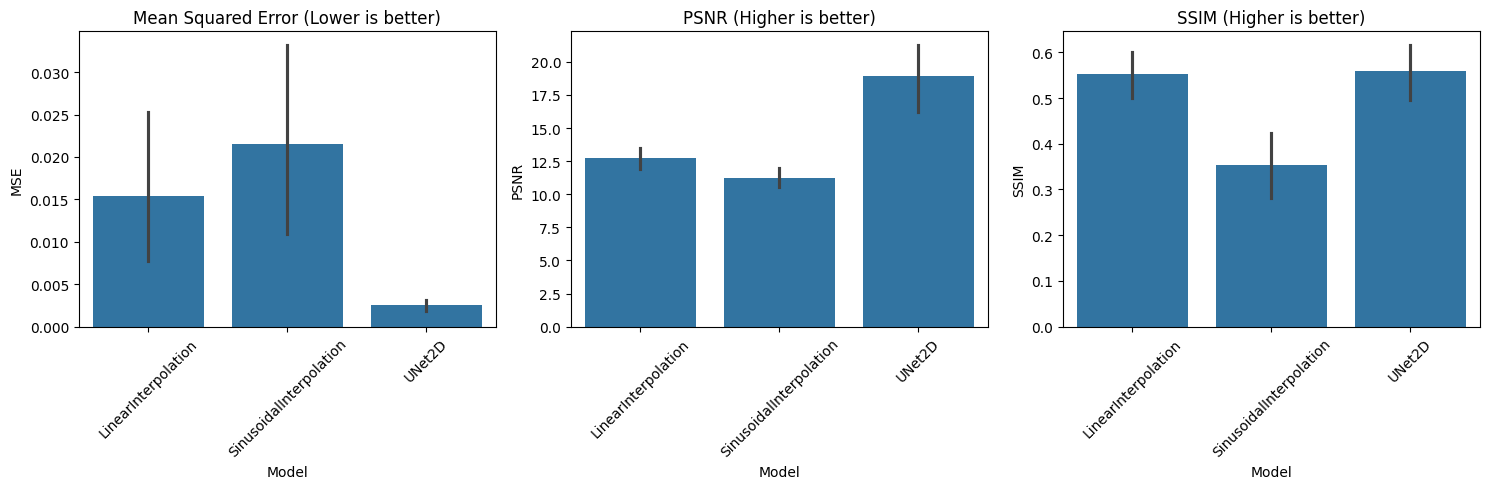

In [2]:
metrics_path = project_root / 'outputs' / 'evaluation' / 'model_comparison_metrics.csv'
if metrics_path.exists():
    df = pd.read_csv(metrics_path)
    
    from IPython.display import display
    
    # Aggregate metrics
    summary = df.groupby('Model')[['MSE', 'PSNR', 'SSIM']].mean().reset_index()
    display(summary)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.barplot(data=df, x='Model', y='MSE', ax=axes[0]).set_title('Mean Squared Error (Lower is better)')
    sns.barplot(data=df, x='Model', y='PSNR', ax=axes[1]).set_title('PSNR (Higher is better)')
    sns.barplot(data=df, x='Model', y='SSIM', ax=axes[2]).set_title('SSIM (Higher is better)')
    
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()
else:
    print(f"Metrics file not found at {metrics_path}. Please run src_2D/evaluate_all.py first.")

## 2. Qualitative Analysis: Visual Comparison of Model Reconstructions

Here we visualize how Linear Interpolation, Sinusoidal Interpolation, and UNet complete the incomplete signal on 10 random samples from the dataset, and also run the SIRT reconstruction to see the resulting image.

In [3]:
device = resolve_compute_device()

# 1. Initialize models
models = {}

# Linear
models['Linear'] = LinearViewInterpolator().to(device)
models['Linear'].eval()

# Sinusoidal
models['Sinusoidal'] = SinusoidalViewInterpolator().to(device)
models['Sinusoidal'].eval()

# UNet
unet = SinogramUNet(in_channels=1, out_channels=1, filters=32).to(device)
unet_weights_path = project_root / 'outputs' / '2d' / 'checkpoints' / 'best_model.pt'
if unet_weights_path.exists():
    try:
        unet.load_state_dict(torch.load(unet_weights_path, map_location=device))
        unet.eval()
        models['UNet2D'] = unet
        print("Successfully loaded UNet2D weights.")
    except Exception as e:
        print(f"Failed to load UNet weights: {e}")
else:
    print(f"UNet weights not found at {unet_weights_path}. Showing only interpolations.")


CUDA is available but cuDNN does not support this GPU architecture; disabling cuDNN.
Using CUDA with cuDNN disabled.
Successfully loaded UNet2D weights.


Running SIRT Reconstructions for Sample 1...


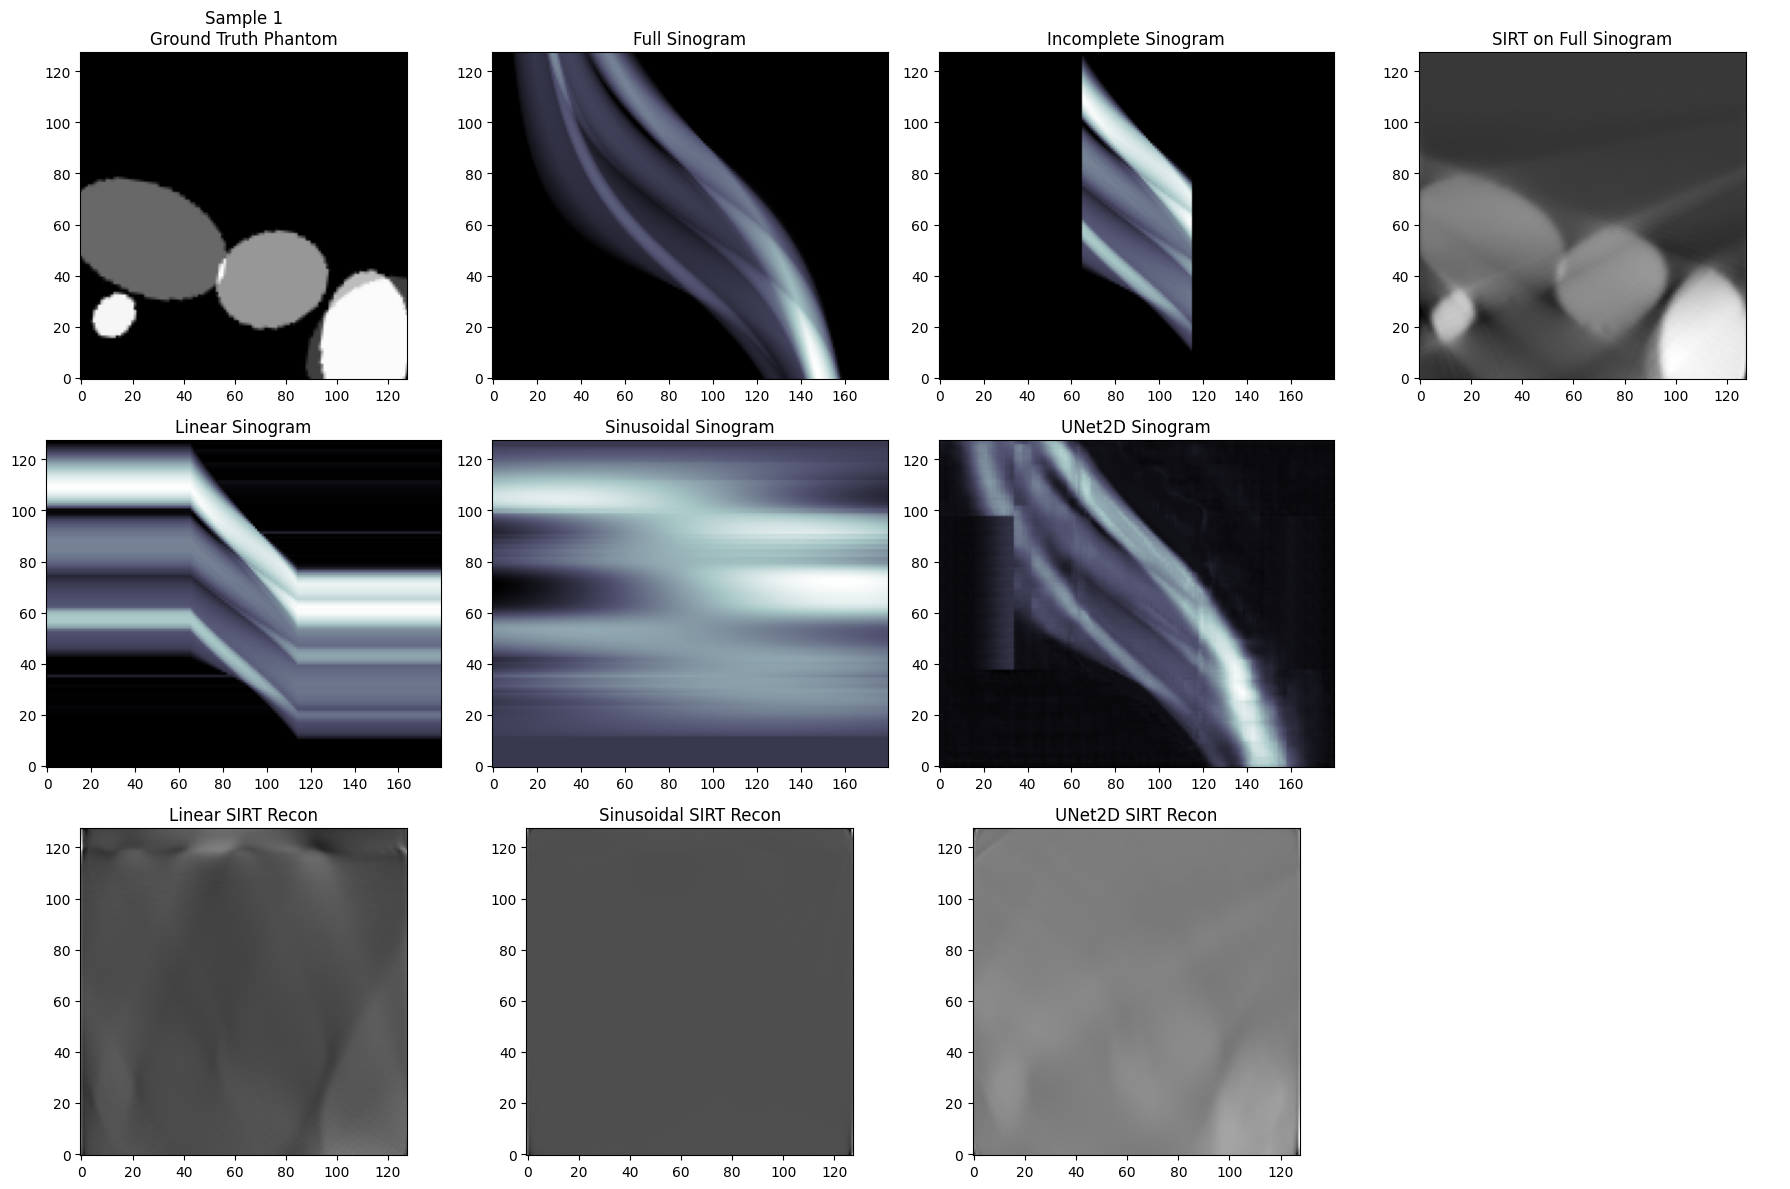

Running SIRT Reconstructions for Sample 2...


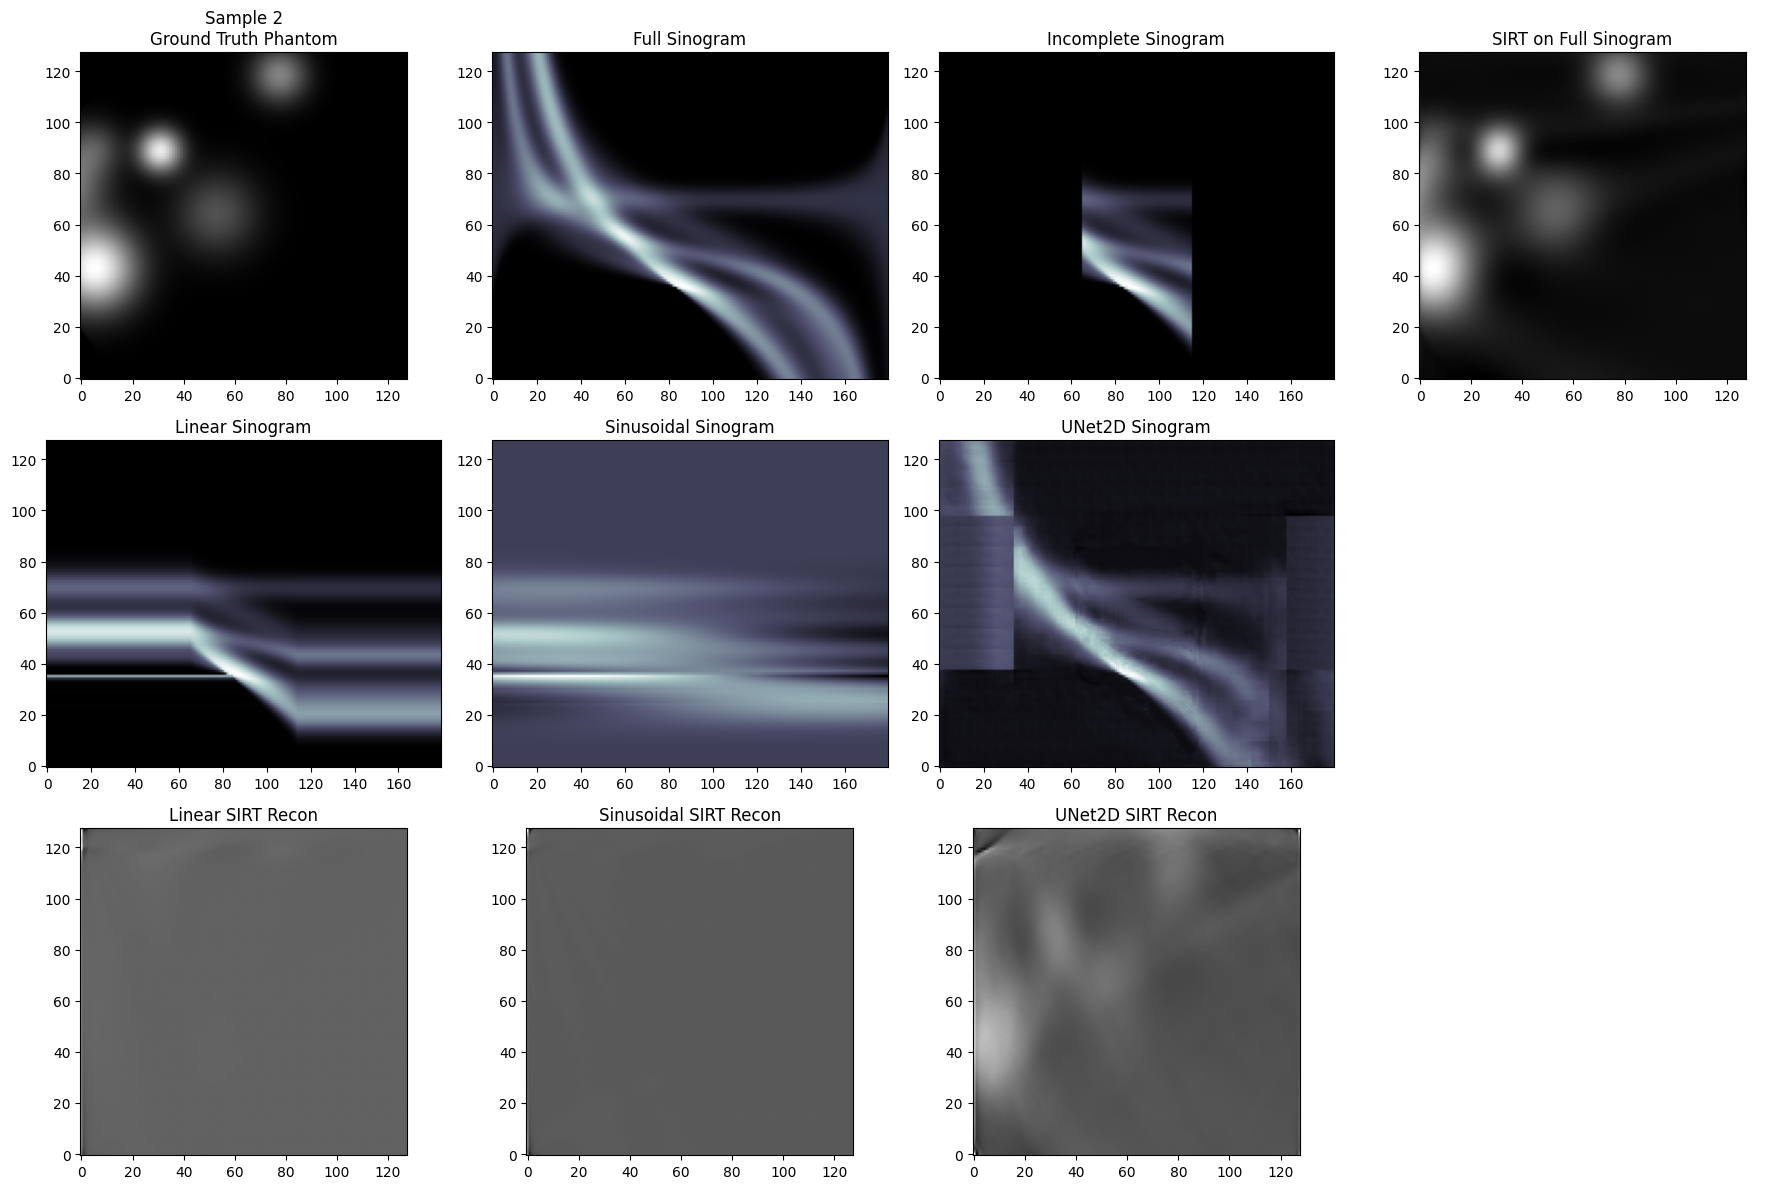

Running SIRT Reconstructions for Sample 3...


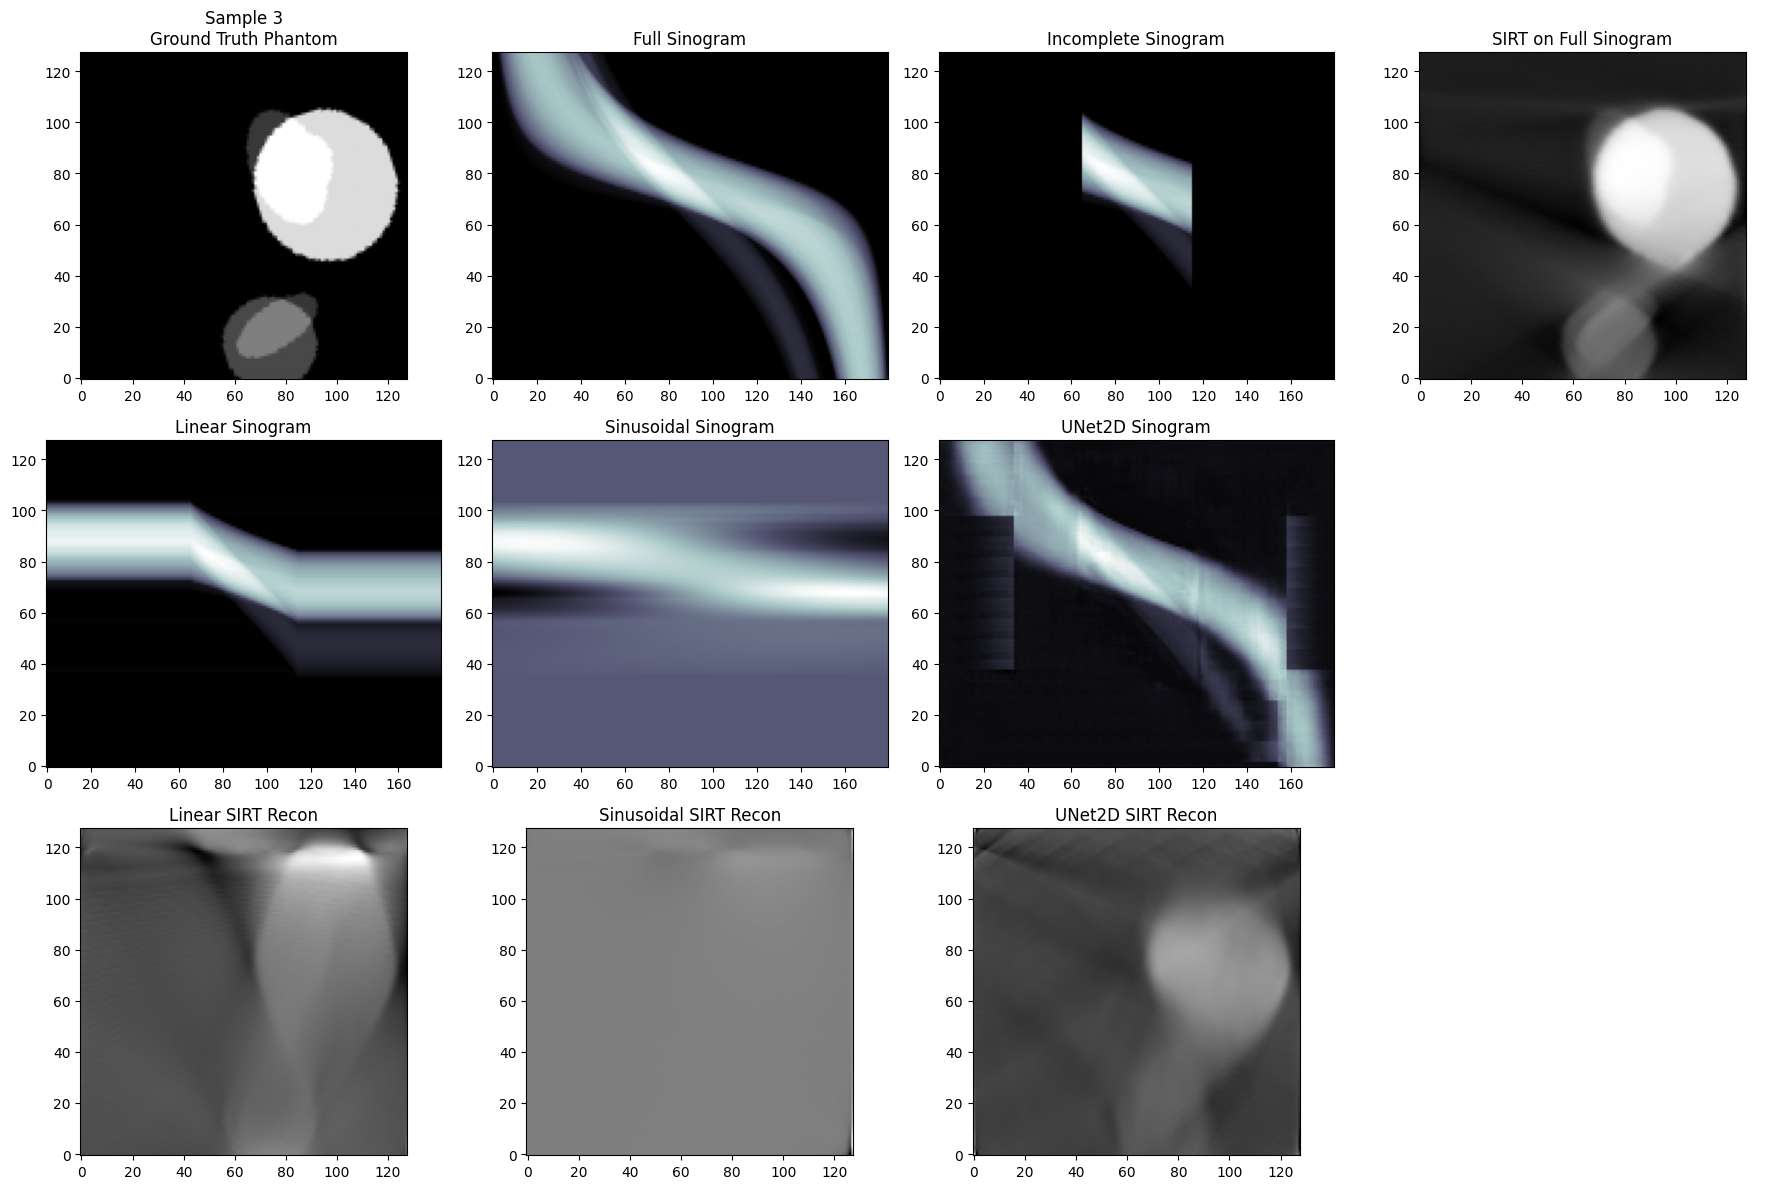

Running SIRT Reconstructions for Sample 4...


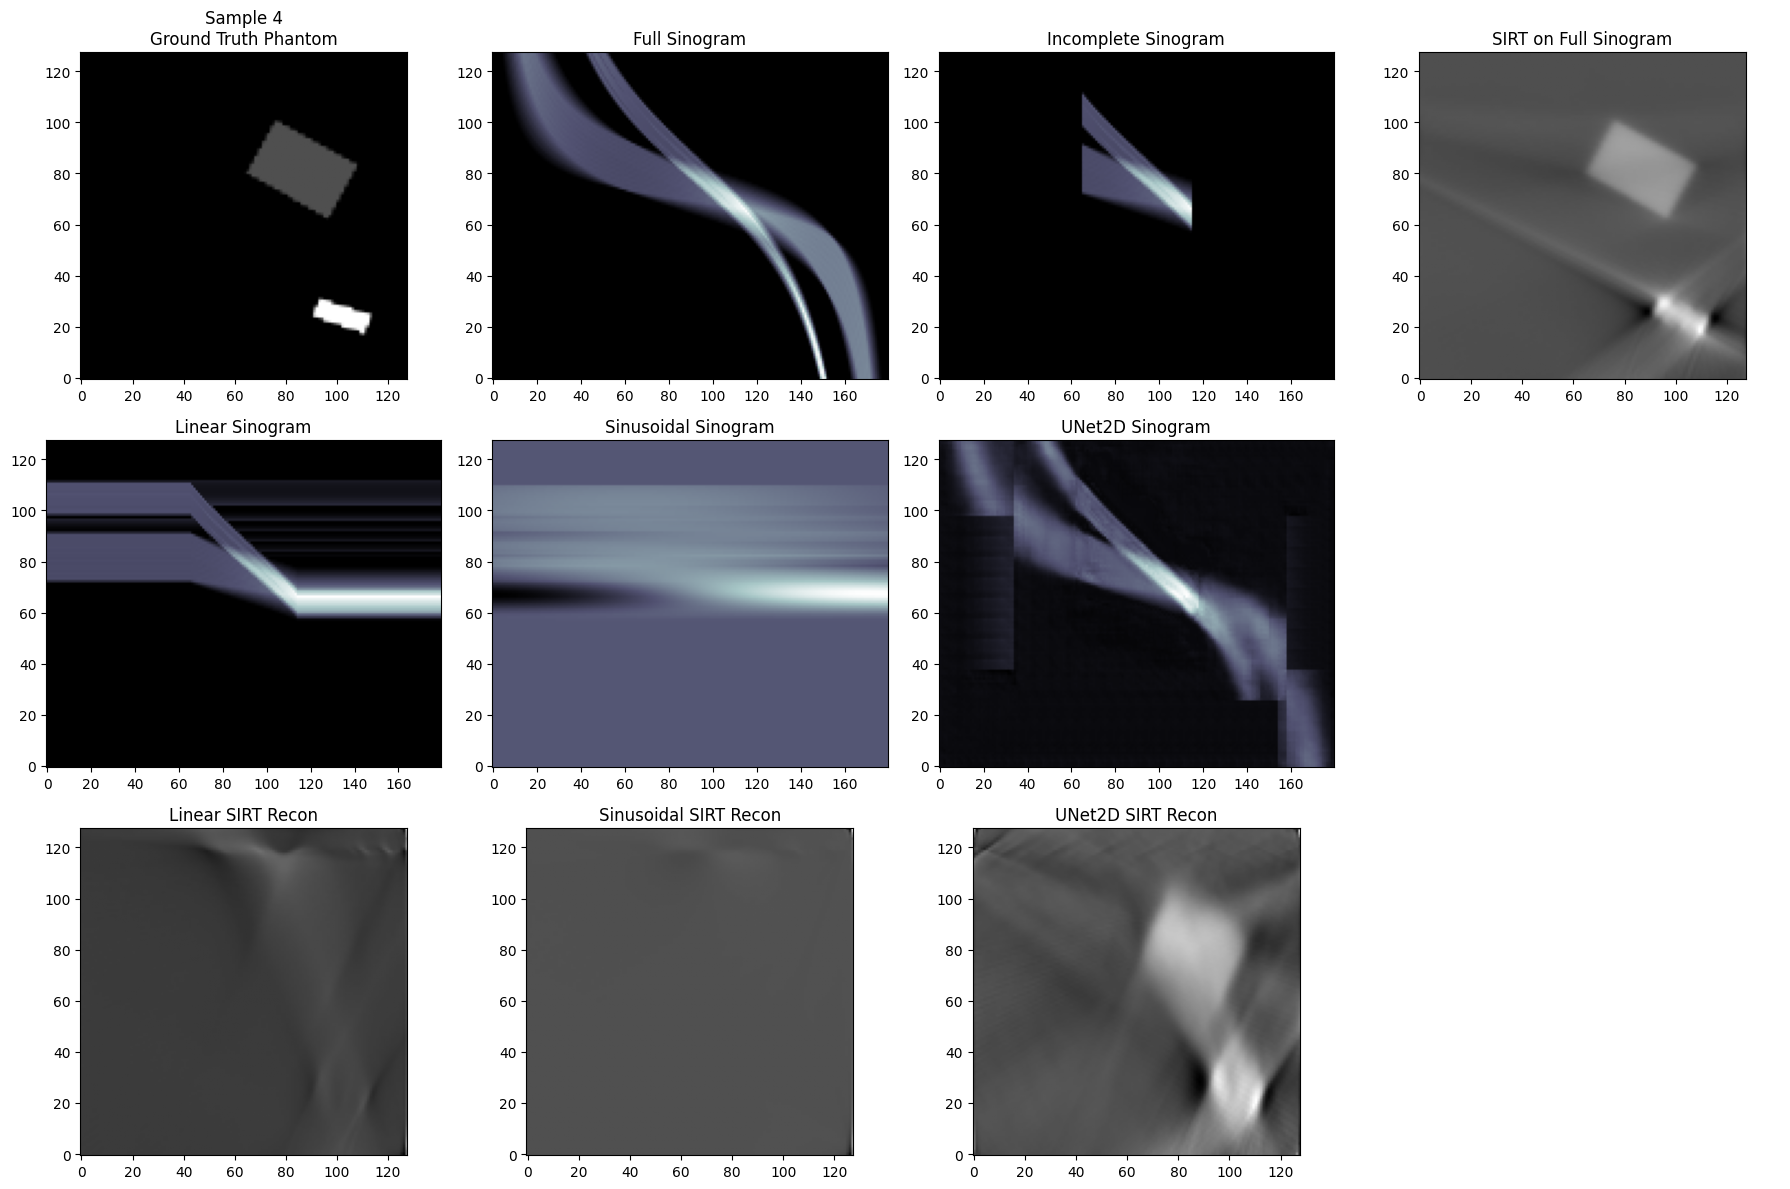

Running SIRT Reconstructions for Sample 5...


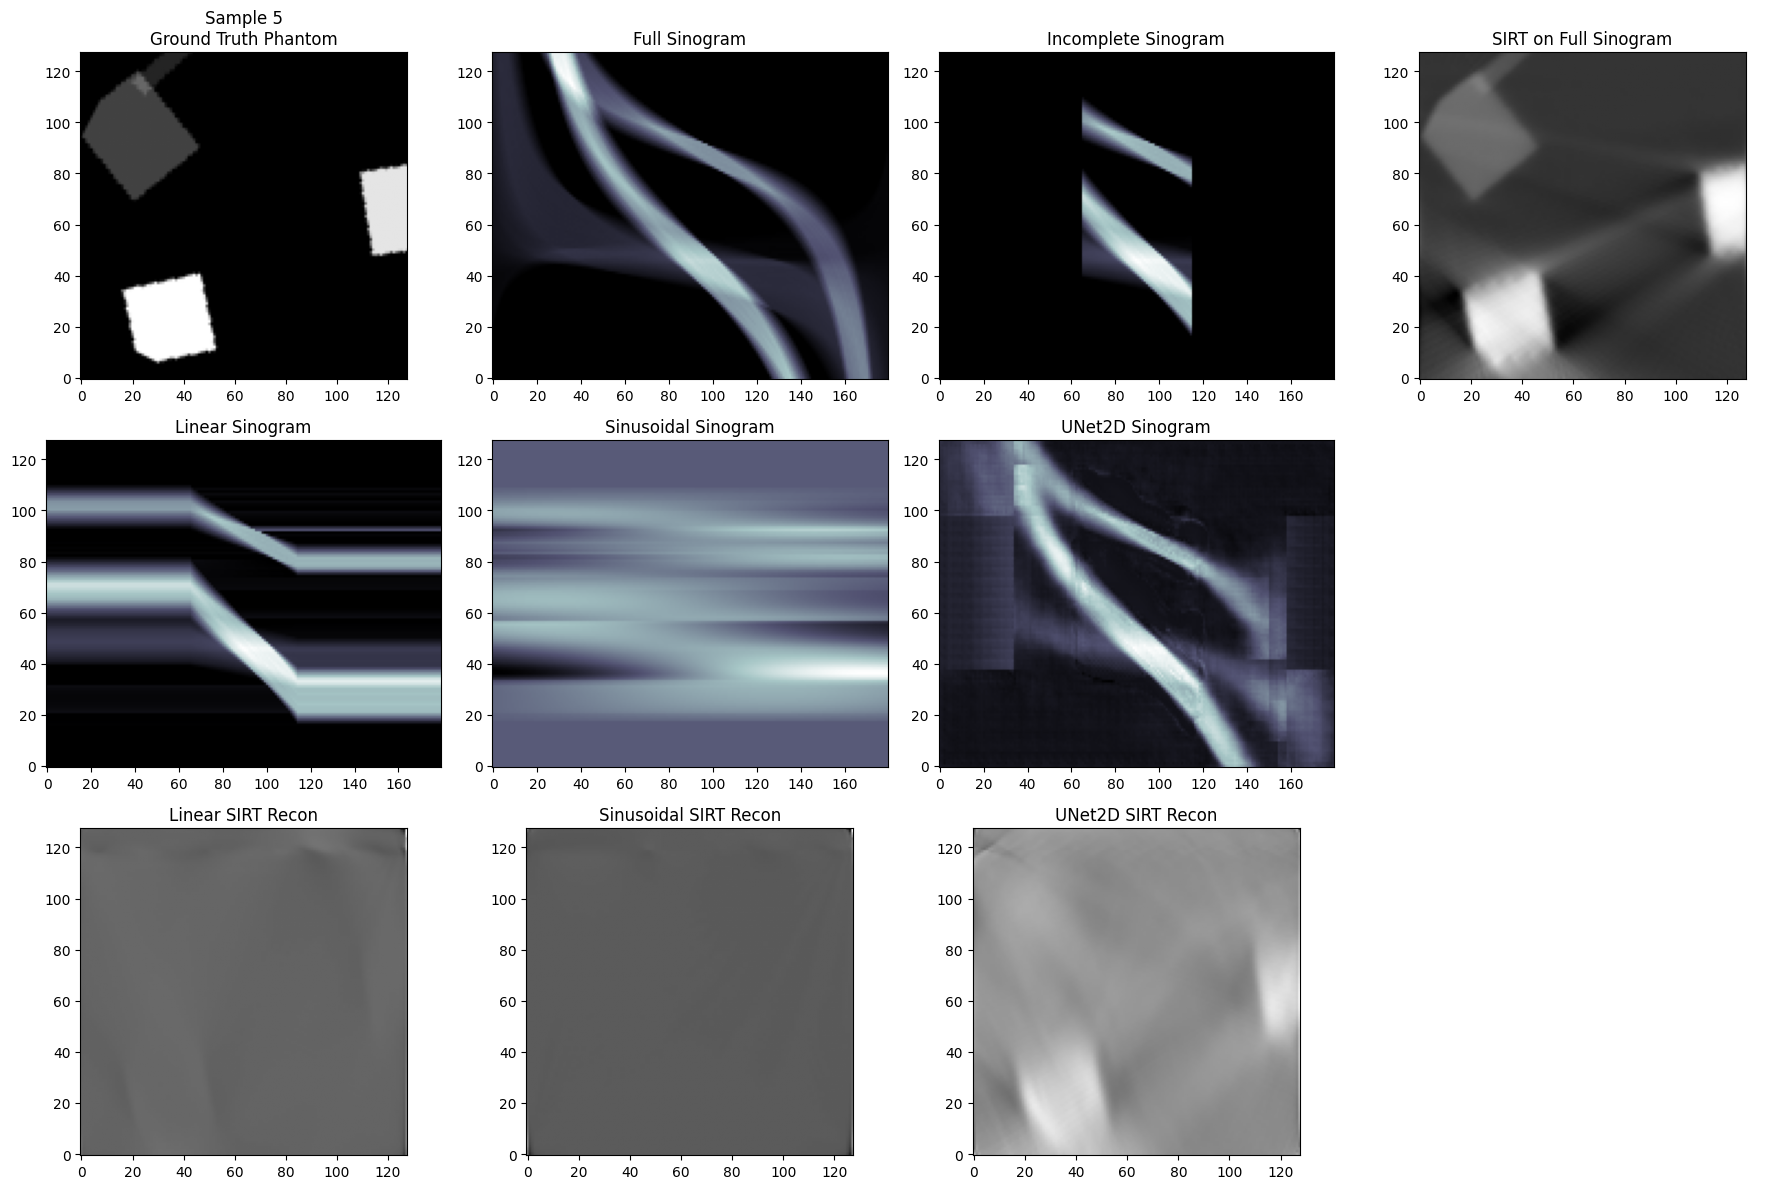

Running SIRT Reconstructions for Sample 6...


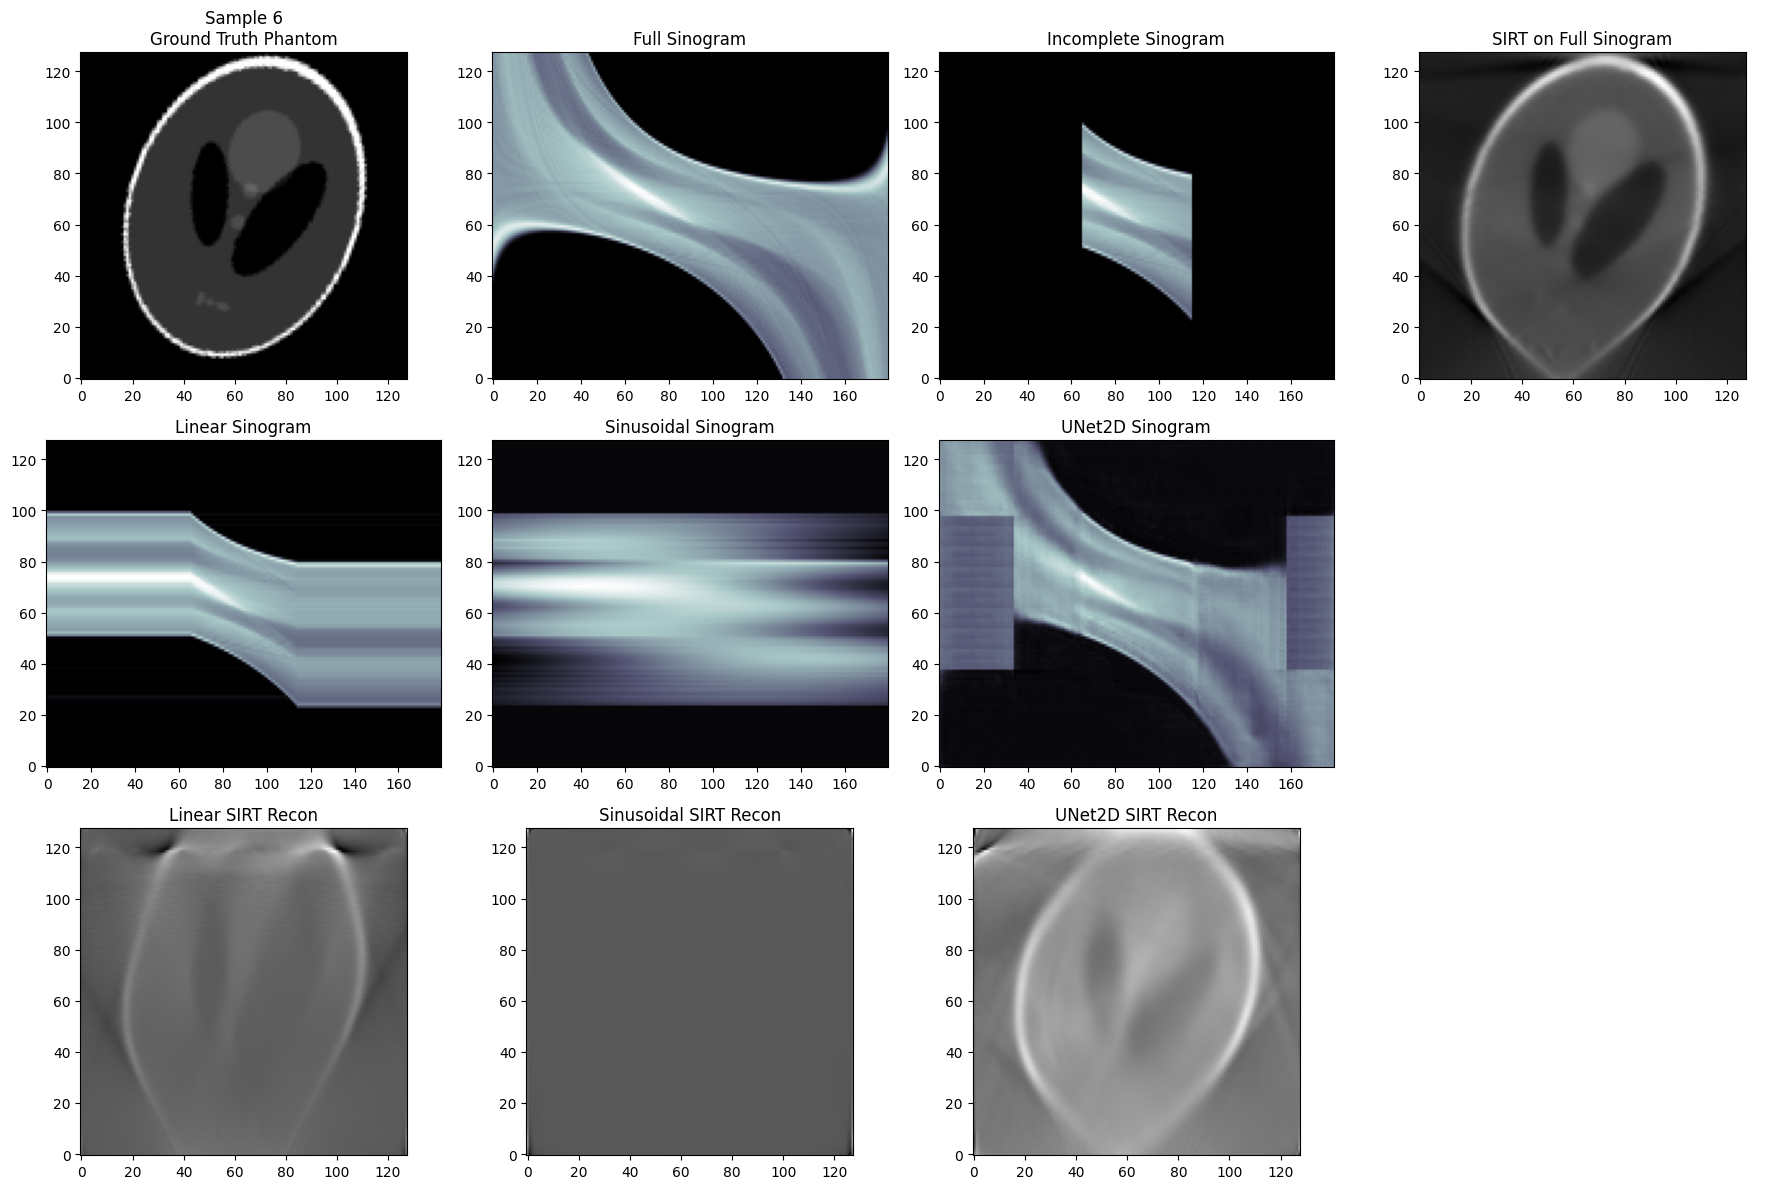

Running SIRT Reconstructions for Sample 7...


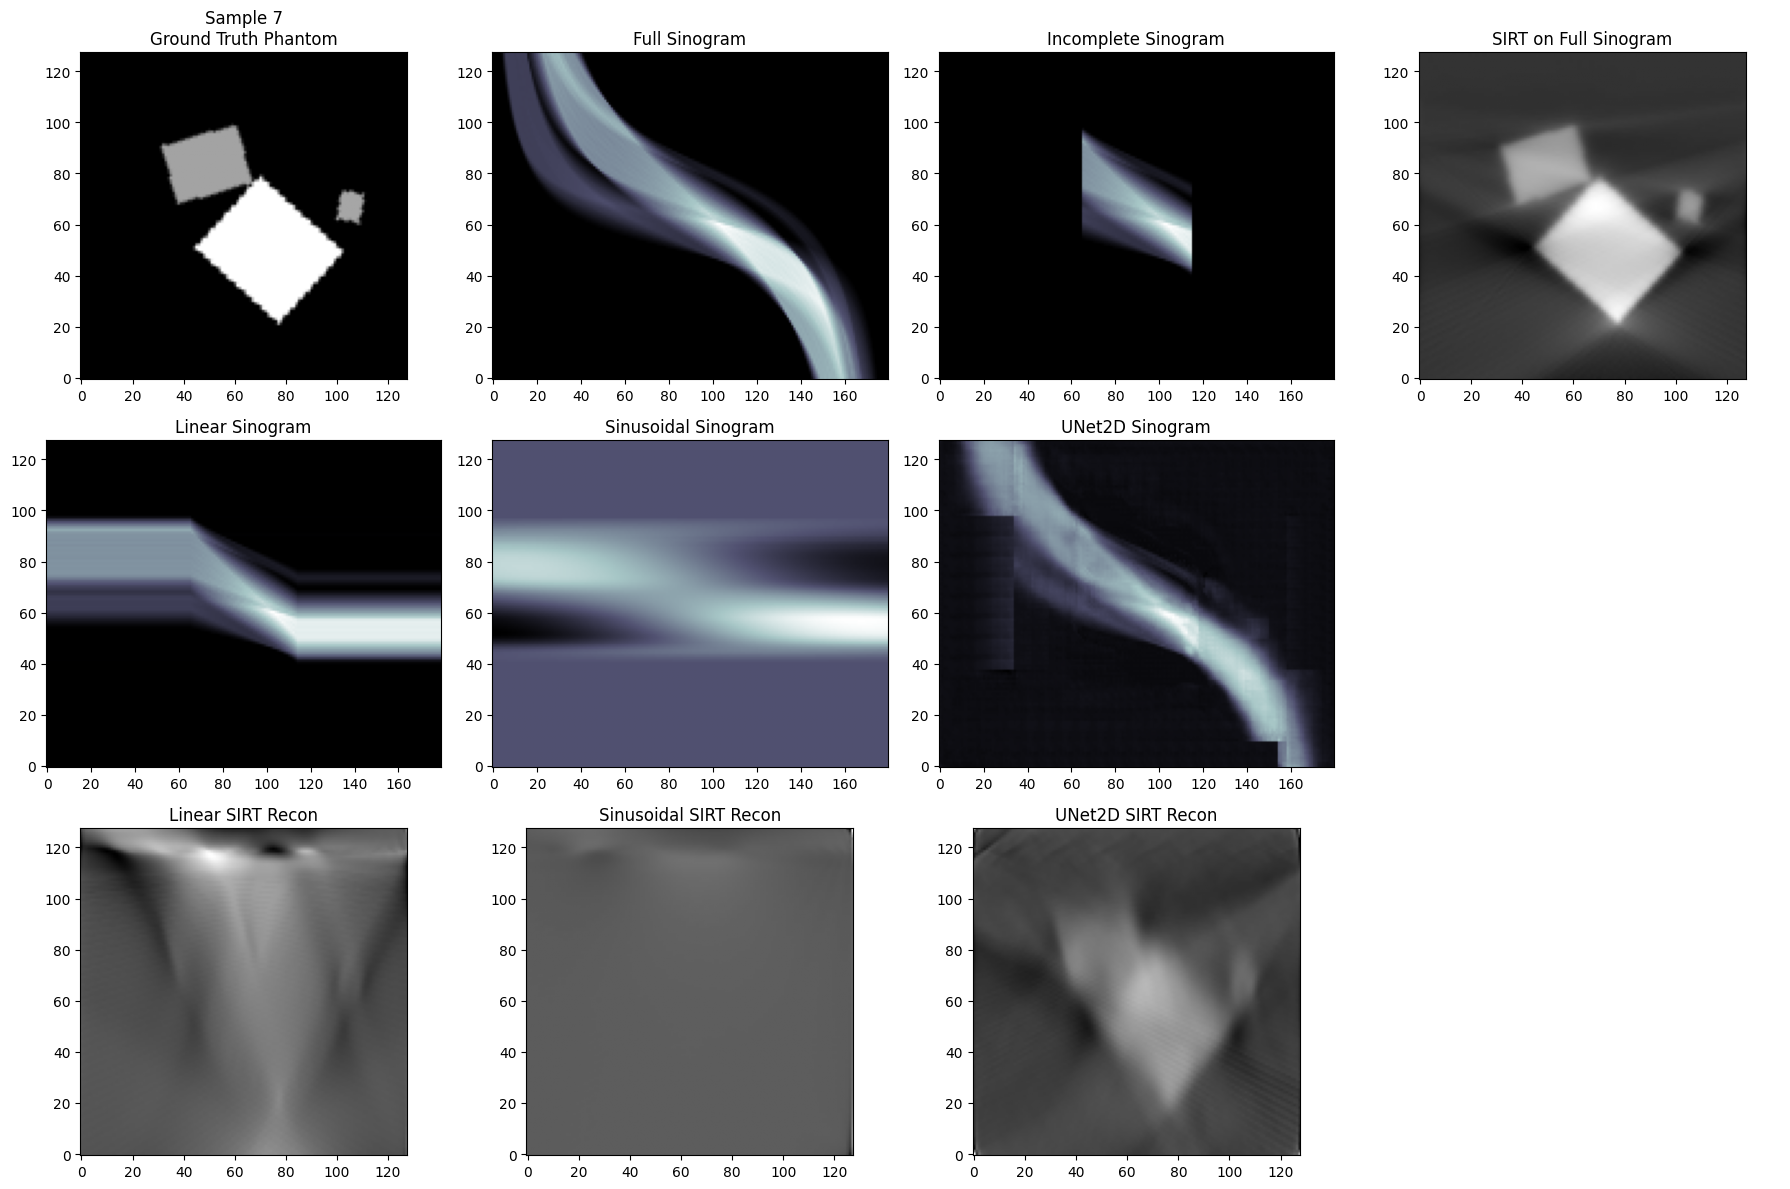

Running SIRT Reconstructions for Sample 8...


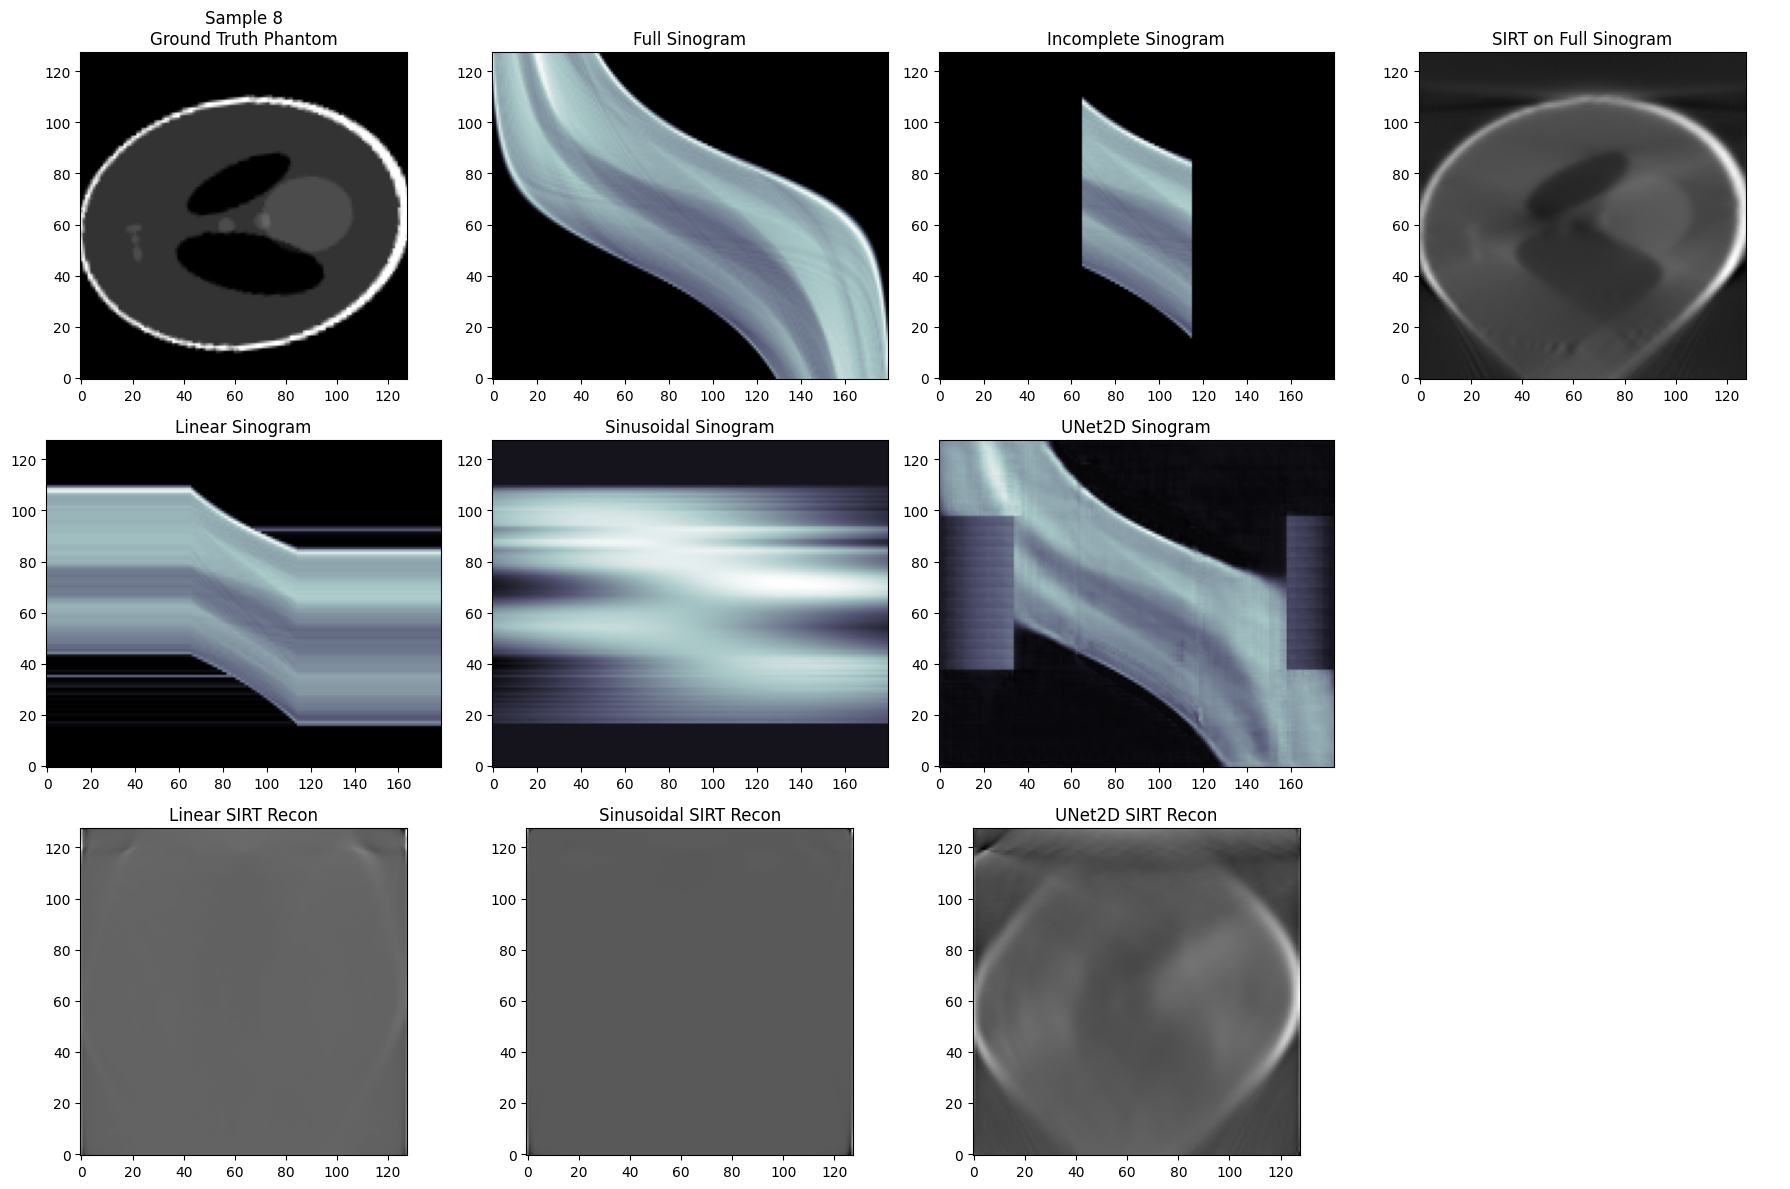

Running SIRT Reconstructions for Sample 9...


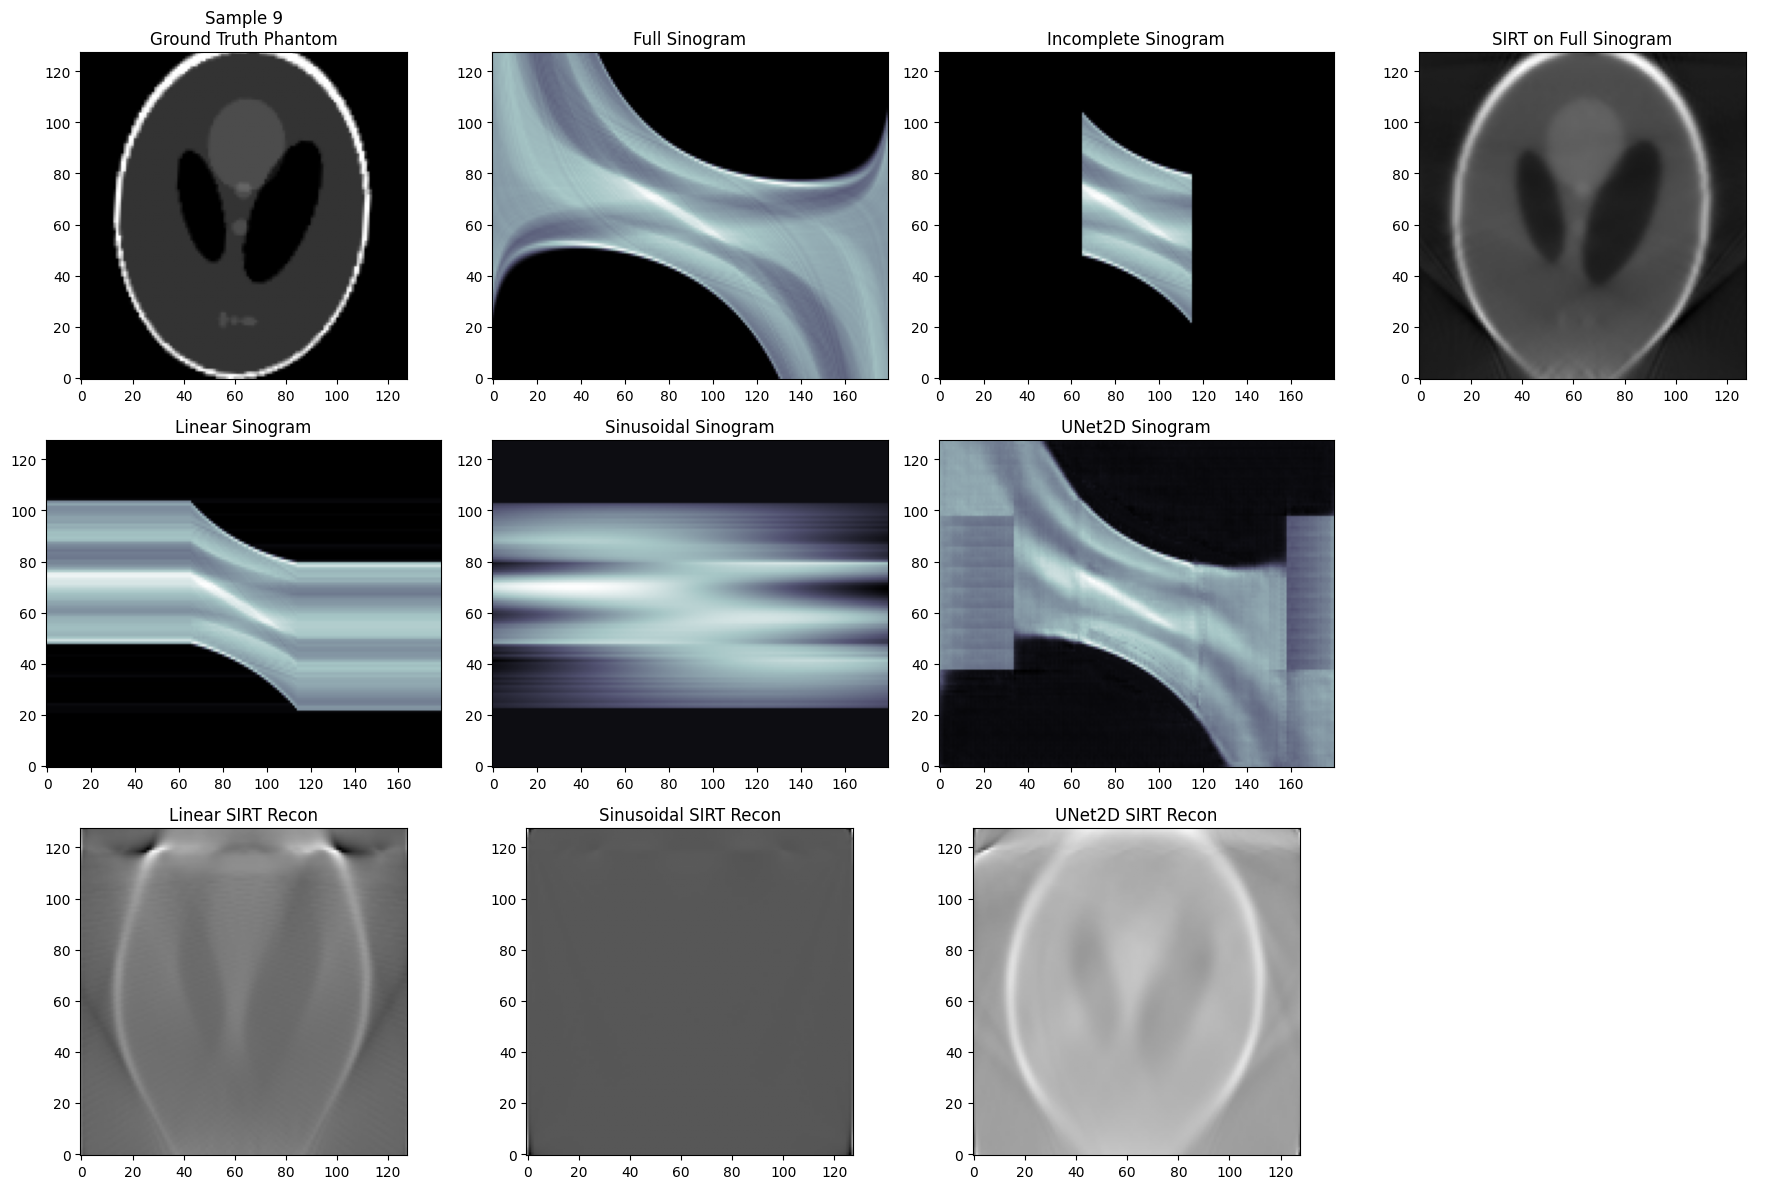

Running SIRT Reconstructions for Sample 10...


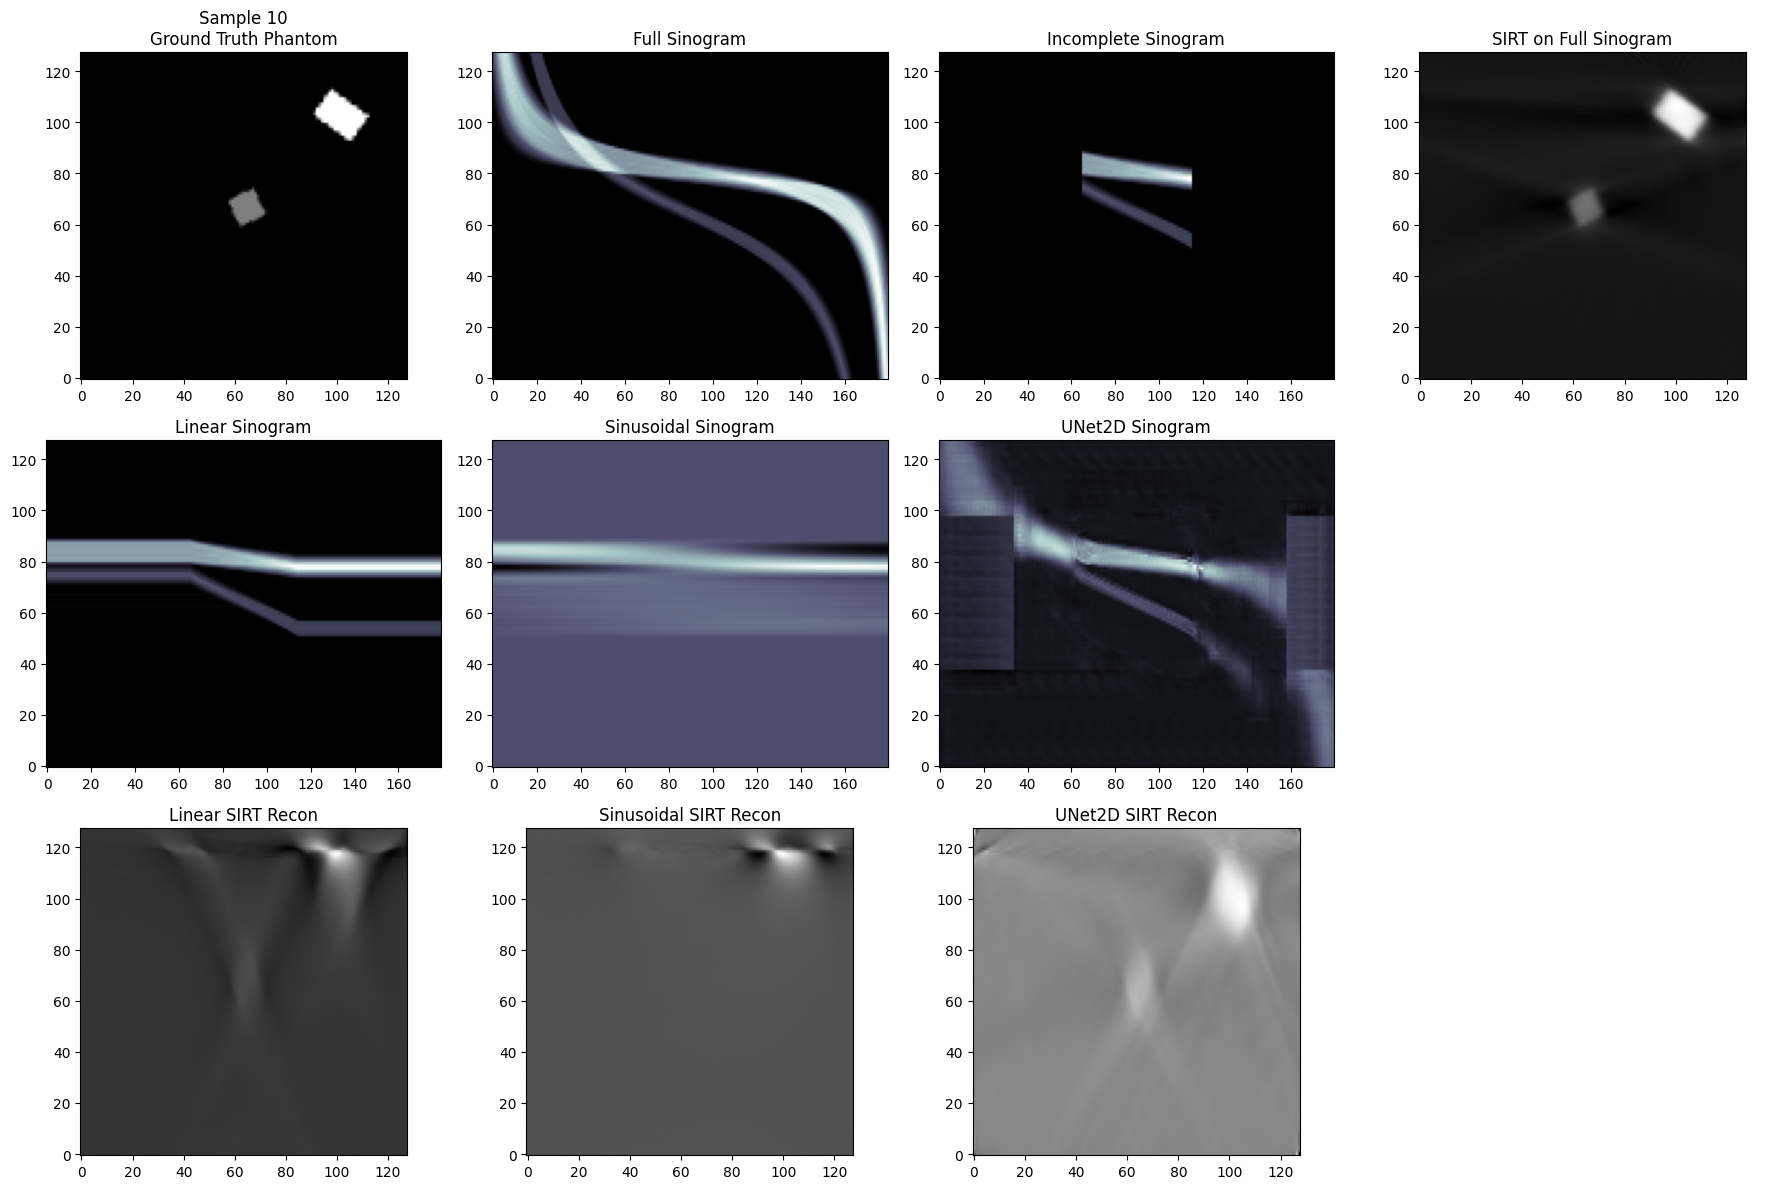

In [4]:
try:
    dataset = SinogramCompletionDataset(n_samples=10, is_validation_or_test=True)
    geometry = DBTGeometryConfig()
    
    # Generate 10 samples to visualize
    for i in range(10):
        incomplete, full, phantom = dataset[i]
        incomplete_batch = incomplete.unsqueeze(0).to(device)
        
        # Predict with all available models
        predictions = {}
        with torch.no_grad():
            for name, model in models.items():
                predictions[name] = model(incomplete_batch).squeeze(0).squeeze(0).cpu().numpy()
                
        # Get ASTRA geometries for SIRT
        proj_geom, vol_geom = build_full_astra_geometries(geometry, tuple(phantom.shape[1:]))
        
        # Run SIRT reconstructions (*100 multiplier as done in evaluate_2d.py)
        print(f"Running SIRT Reconstructions for Sample {i+1}...")
        full_sirt = reconstruct_volume_sirt(full.squeeze(0).cpu().numpy() * 100.0, proj_geom, vol_geom, n_iterations=30)
        inc_sirt = reconstruct_volume_sirt(incomplete.squeeze(0).cpu().numpy() * 100.0, proj_geom, vol_geom, n_iterations=30)
        
        sirts = {}
        for name, pred in predictions.items():
            sirts[name] = reconstruct_volume_sirt(pred * 100.0, proj_geom, vol_geom, n_iterations=30)
        
        # Plotting - 3 Rows: Reference, Sinograms, SIRT
        num_cols = max(4, len(predictions))
        fig, axes = plt.subplots(3, num_cols, figsize=(4.5 * num_cols, 12))
        
        # ROW 1: References
        axes[0, 0].imshow(phantom.squeeze(0).cpu().numpy(), cmap='gray', origin='lower')
        axes[0, 0].set_title(f"Sample {i+1}\nGround Truth Phantom")
        
        axes[0, 1].imshow(full.squeeze(0).cpu().numpy().T, cmap='bone', origin='lower', aspect='auto')
        axes[0, 1].set_title("Full Sinogram")
        
        axes[0, 2].imshow(incomplete.squeeze(0).cpu().numpy().T, cmap='bone', origin='lower', aspect='auto')
        axes[0, 2].set_title("Incomplete Sinogram")
        
        if full_sirt is not None:
            axes[0, 3].imshow(full_sirt, cmap='gray', origin='lower')
            axes[0, 3].set_title("SIRT on Full Sinogram")
        else:
            axes[0, 3].set_title("ASTRA not available")
            
        for j in range(4, num_cols):
            axes[0, j].axis('off')
        
        # ROW 2: Model Sinograms
        ax_idx = 0
        for name, pred in predictions.items():
            axes[1, ax_idx].imshow(pred.T, cmap='bone', origin='lower', aspect='auto')
            axes[1, ax_idx].set_title(f"{name} Sinogram")
            ax_idx += 1
        for j in range(ax_idx, num_cols):
            axes[1, j].axis('off')
            
        # ROW 3: Model SIRT Reconstructions
        ax_idx = 0
        for name, reco in sirts.items():
            if reco is not None:
                axes[2, ax_idx].imshow(reco, cmap='gray', origin='lower')
                axes[2, ax_idx].set_title(f"{name} SIRT Recon")
            else:
                axes[2, ax_idx].set_title("ASTRA not available")
            ax_idx += 1
        for j in range(ax_idx, num_cols):
            axes[2, j].axis('off')
            
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"An error occurred during dataset loading or visualization: {e}")

## SinoSheavesNN Analysis

In this section, we evaluate the Physics-Informed **Sheaf Neural Network (SNN)** architecture. 
The SNN natively respects the rotational symmetries of the Radon transform by passing features through $SO(2)$ restriction maps, while the Helgason-Ludwig moments constrain the mass and center of mass of the predictions.

Below, we load the model, perform a forward pass, compute the physical consistency metrics, and visualize the predicted sinogram.

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
from src_2D.geometry.dbt_geometry_2d import DBTGeometry
from src_2D.data.dataset_2d import SinogramCompletionDataset
from src_2D.models.SinoSheavesNN.snn_model import SinoSheafNet
from src_2D.models.SinoSheavesNN.graph_data import create_sinogram_data
from src_2D.models.SinoSheavesNN.physics_loss import HelgasonLudwigLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = DBTGeometryConfig()
geom = DBTGeometry(
    angles=config.full_angles,
    src_radius=config.src_radius_mm,
    det_radius=config.det_radius_mm,
    det_col_count=config.det_col_count,
    det_pixel_size=config.det_pixel_size_mm,
)

# 1. Load Dataset
dataset = SinogramCompletionDataset(n_samples=5, geometry_config=config, device=str(device), is_validation_or_test=True)

# 2. Initialize Model
# NOTE: Update the hyperparameters based on your best Optuna trial!
model_path = project_root / "outputs" / "2d" / "best_snn_model.pth"
model = SinoSheafNet(num_stalks=32, num_layers=6).to(device)

if model_path.exists():
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Loaded trained SinoSheavesNN model.")
else:
    print("Warning: Pre-trained weights not found. Using untrained model for demonstration.\nTrain the model using run_training.py to see accurate results.")

model.eval()

Train the model using run_training.py to see accurate results.


SinoSheafNet(
  (encoder): Linear(in_features=1, out_features=64, bias=True)
  (convs): ModuleList(
    (0-5): 6 x SheafConv(32, 32)
  )
  (decoder): Linear(in_features=64, out_features=1, bias=True)
)

--- SinoSheavesNN Performance ---
SSIM: 0.1642
Helgason-Ludwig 0th Moment (Mass Variance): 0.0098
Helgason-Ludwig 1st Moment (Center of Mass Residual): 13.7621


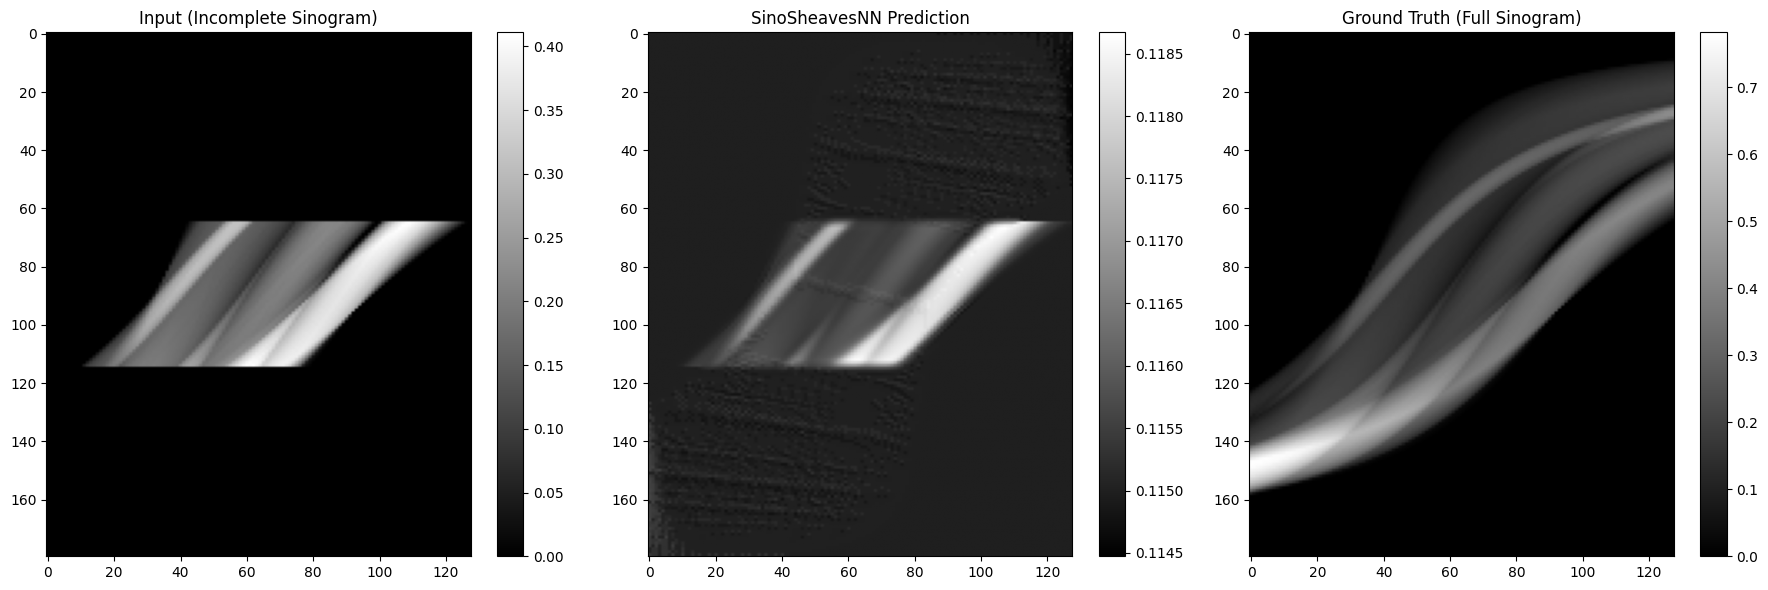

In [9]:
# 3. Qualitative Evaluation & Physics Verification
inc_sino, full_sino, phantom = dataset[0]

inc_sino_tensor = inc_sino[0].to(device)
target_sino_tensor = full_sino[0].to(device)

# Build the Graph Data dynamically
graph_data = create_sinogram_data(inc_sino_tensor, geom).to(device)

with torch.no_grad():
    out = model(graph_data)
    pred_sino = out.view(geom.num_views, geom.det_col_count)
    
# Physics Metrics
hl_loss = HelgasonLudwigLoss(geom).to(device)
m0_loss, m1_loss = hl_loss(pred_sino)

from skimage.metrics import structural_similarity as ssim
target_np = target_sino_tensor.cpu().numpy()
pred_np = pred_sino.cpu().numpy()
d_range = max(target_np.max() - target_np.min(), 1.0)
snn_ssim = ssim(target_np, pred_np, data_range=d_range)

print("--- SinoSheavesNN Performance ---")
print(f"SSIM: {snn_ssim:.4f}")
print(f"Helgason-Ludwig 0th Moment (Mass Variance): {m0_loss.item():.4f}")
print(f"Helgason-Ludwig 1st Moment (Center of Mass Residual): {m1_loss.item():.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(inc_sino_tensor.cpu().numpy(), cmap='gray', aspect='auto')
axes[0].set_title("Input (Incomplete Sinogram)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pred_np, cmap='gray', aspect='auto')
axes[1].set_title("SinoSheavesNN Prediction")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(target_np, cmap='gray', aspect='auto')
axes[2].set_title("Ground Truth (Full Sinogram)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()